# Customer & Product Business Analysis
## Project 2 -- Python Validation & Visualization Layer

This notebook is **not** a standalone analysis. The core business analysis
lives in `/sql` (`01_data_validation.sql` -> `04_seller_analysis.sql`),
which is the source of truth for every number in this project's README.

This notebook's job is narrower:

1. Reproduce the SQL logic in Python/pandas and confirm the same numbers come out
2. Produce distribution views and charts that are awkward to do in pure SQL
3. Generate the chart images used in the dashboard

No new business conclusions are introduced here that aren't already
established by the SQL analysis.


---
## 01. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

COLOR_PRIMARY = '#EE4D2D'   # Shopee-orange accent, used sparingly
COLOR_NEUTRAL = '#4A4A4A'
COLOR_LIGHT   = '#B0B0B0'

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)


In [2]:
# CSVs are expected in ../data/ (see data/README.md for the five required files
# and where to obtain/place them -- raw data is not committed to this repo).
DATA_DIR = '../data/'

customers    = pd.read_csv(DATA_DIR + 'shopee_customers_thailand.csv', parse_dates=['registration_date'])
orders       = pd.read_csv(DATA_DIR + 'shopee_orders_thailand.csv', parse_dates=['order_date'])
order_items  = pd.read_csv(DATA_DIR + 'shopee_order_items_thailand.csv')
products     = pd.read_csv(DATA_DIR + 'shopee_products_thailand.csv')
sellers      = pd.read_csv(DATA_DIR + 'shopee_sellers_thailand.csv')

print(f"customers:   {len(customers):>7,} rows")
print(f"orders:      {len(orders):>7,} rows")
print(f"order_items: {len(order_items):>7,} rows")
print(f"products:    {len(products):>7,} rows")
print(f"sellers:     {len(sellers):>7,} rows")


customers:    60,000 rows
orders:      300,000 rows
order_items: 480,481 rows
products:      4,880 rows
sellers:         200 rows


---
## 02. Validate SQL Outputs

Before doing anything else, reproduce the key numbers from each `.sql`
file in pandas and confirm they match. If any of these assertions fail,
something is inconsistent between the SQL analysis and this notebook --
that is treated as a bug to fix, not a discrepancy to explain away.

In [3]:
# ---- Reproduce 01_data_validation.sql -----------------------------------

# Realized revenue definition check: orders.subtotal_amount includes
# cancelled/refunded items (matches ALL items, not just Completed)
oi_sum_all = order_items.groupby('order_id')['line_total'].sum()
merged = orders.set_index('order_id')[['subtotal_amount']].join(oi_sum_all.rename('sum_all'))
mismatch_all = (merged['subtotal_amount'] - merged['sum_all']).abs() > 0.05
assert mismatch_all.sum() == 0, "subtotal_amount should equal sum of ALL items"

oi_sum_completed = order_items[order_items['item_status']=='Completed'].groupby('order_id')['line_total'].sum()
merged2 = orders.set_index('order_id')[['subtotal_amount']].join(oi_sum_completed.rename('sum_completed')).fillna(0)
mismatch_completed = (merged2['subtotal_amount'] - merged2['sum_completed']).abs() > 0.05
assert mismatch_completed.sum() == 105429, f"expected 105,429 mismatches, got {mismatch_completed.sum()}"

completed_order_ids = set(order_items[order_items['item_status']=='Completed']['order_id'])
orders_no_completed = (~orders['order_id'].isin(completed_order_ids)).sum()
assert orders_no_completed == 49951, f"expected 49,951, got {orders_no_completed}"

print("PASS -- 01_data_validation.sql numbers reproduced:")
print(f"  Revenue mismatches (subtotal vs completed-only): {mismatch_completed.sum():,}")
print(f"  Orders with zero realized revenue: {orders_no_completed:,} "
      f"({orders_no_completed/len(orders)*100:.1f}%)")


PASS -- 01_data_validation.sql numbers reproduced:
  Revenue mismatches (subtotal vs completed-only): 105,429
  Orders with zero realized revenue: 49,951 (16.7%)


In [4]:
# ---- Reproduce 02_customer_analysis.sql ----------------------------------

completed_items = order_items[order_items['item_status']=='Completed']
oi_dated = completed_items.merge(orders[['order_id','order_date','customer_id']], on='order_id')

monetary  = oi_dated.groupby('customer_id')['line_total'].sum().rename('monetary')
frequency = oi_dated.groupby('customer_id')['order_id'].nunique().rename('frequency')
max_date  = orders['order_date'].max()
last_purchase = oi_dated.groupby('customer_id')['order_date'].max()
recency = (max_date - last_purchase).dt.days.rename('recency')

rfm = pd.concat([recency, frequency, monetary], axis=1).dropna().reset_index()
assert len(rfm) == 55822, f"expected 55,822 eligible customers, got {len(rfm)}"

rfm = rfm.merge(customers[['customer_id','registration_date']], on='customer_id')
cutoff = orders['order_date'].max() - pd.DateOffset(months=3)
rfm['tenure_group'] = np.where(rfm['registration_date'] >= cutoff, 'Recent (<3mo tenure)', 'Established')

def freq_band(f):
    if f == 1: return '1: One-time'
    elif f <= 3: return '2-3: Occasional repeat'
    elif f <= 5: return '4-5: Regular'
    elif f <= 8: return '6-8: Frequent'
    else: return '9+: Power buyer'
rfm['freq_band'] = rfm['frequency'].apply(freq_band)

def segment(row):
    if row['tenure_group'] == 'Recent (<3mo tenure)':
        return 'B0: New / recently acquired'
    if row['frequency'] == 1:
        return 'B5: One-time buyer' if row['recency'] <= 90 else 'B6: One-time buyer, inactive'
    if row['frequency'] >= 6:
        return 'B1: High-frequency, engaged' if row['recency'] <= 90 else 'B2: High-value, declining engagement'
    if 2 <= row['frequency'] <= 5:
        return 'B3: Regular/occasional, active' if row['recency'] <= 180 else 'B4: Regular/occasional, inactive'
    return 'B4: Regular/occasional, inactive'
rfm['customer_segment'] = rfm.apply(segment, axis=1)

b2_count = (rfm['customer_segment'] == 'B2: High-value, declining engagement').sum()
assert b2_count == 1906, f"expected B2 = 1,906, got {b2_count}"

watchlist = rfm[(rfm['frequency'] >= 6) & (rfm['recency'] > 180)]
assert len(watchlist) == 547, f"expected watchlist = 547, got {len(watchlist)}"

print("PASS -- 02_customer_analysis.sql numbers reproduced:")
print(f"  Eligible customers: {len(rfm):,}")
print(f"  B2 (high-value, declining engagement): {b2_count:,}")
print(f"  Stricter watchlist (freq>=6, recency>180d): {len(watchlist):,}, "
      f"revenue \u0e3f{watchlist['monetary'].sum():,.0f}")


PASS -- 02_customer_analysis.sql numbers reproduced:
  Eligible customers: 55,822
  B2 (high-value, declining engagement): 1,906
  Stricter watchlist (freq>=6, recency>180d): 547, revenue ฿48,240,540


In [5]:
# ---- Reproduce 03_category_analysis.sql (category revenue mix) ----------

cat_completed = completed_items.merge(products[['product_id','category']], on='product_id')
cat_completed = cat_completed.merge(orders[['order_id','customer_id']], on='order_id')
cat_revenue = cat_completed.groupby('category')['line_total'].sum().sort_values(ascending=False)
cat_share = (cat_revenue / cat_revenue.sum() * 100).round(1)

assert abs(cat_share['Home'] - 62.4) < 0.2, f"expected Home ~62.4%, got {cat_share['Home']}"
assert abs(cat_share['Electronics'] - 33.8) < 0.2, f"expected Electronics ~33.8%, got {cat_share['Electronics']}"

print("PASS -- 03_category_analysis.sql revenue mix reproduced:")
print(cat_share.to_string())


PASS -- 03_category_analysis.sql revenue mix reproduced:
category
Home           62.4
Electronics    33.8
Fashion         2.9
Groceries       0.5
Beauty          0.4


In [6]:
# ---- Reproduce 04_seller_analysis.sql (catalog-size confound) -----------

n_products = products.groupby('seller_id').size().rename('n_products')
seller_full = sellers.set_index('seller_id').join(n_products)

fbs_products = seller_full.groupby('fbs_standard')['n_products'].agg(['min','max'])
assert fbs_products.loc['FBS','min'] == 16 and fbs_products.loc['FBS','max'] == 16
assert fbs_products.loc['Standard','min'] == 28 and fbs_products.loc['Standard','max'] == 28

print("PASS -- 04_seller_analysis.sql catalog-size confound reproduced:")
print(fbs_products)


PASS -- 04_seller_analysis.sql catalog-size confound reproduced:
              min  max
fbs_standard          
FBS            16   16
Standard       28   28


All four SQL files' key numbers reproduce exactly in pandas. The rest of
this notebook builds on the `rfm` (customer_segments) table computed above.

---
## 03. Customer Analysis

**Finding:** purchase frequency showed the strongest and most consistent
association with customer value in this dataset.

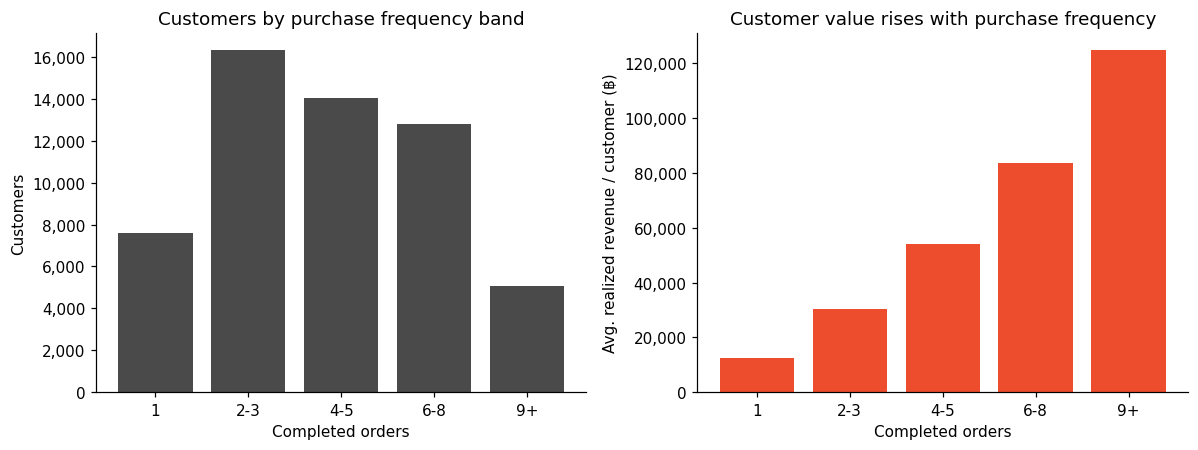

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# --- Left: customers per frequency band ---
band_order = ['1: One-time','2-3: Occasional repeat','4-5: Regular','6-8: Frequent','9+: Power buyer']
band_counts = rfm['freq_band'].value_counts().reindex(band_order)

axes[0].bar(range(len(band_counts)), band_counts.values, color=COLOR_NEUTRAL)
axes[0].set_xticks(range(len(band_counts)))
axes[0].set_xticklabels([b.split(':')[0] for b in band_order])
axes[0].set_xlabel('Completed orders')
axes[0].set_ylabel('Customers')
axes[0].set_title('Customers by purchase frequency band')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# --- Right: avg revenue per customer by band (the key finding) ---
band_revenue = rfm.groupby('freq_band', observed=True)['monetary'].mean().reindex(band_order)
axes[1].bar(range(len(band_revenue)), band_revenue.values, color=COLOR_PRIMARY)
axes[1].set_xticks(range(len(band_revenue)))
axes[1].set_xticklabels([b.split(':')[0] for b in band_order])
axes[1].set_xlabel('Completed orders')
axes[1].set_ylabel('Avg. realized revenue / customer (\u0e3f)')
axes[1].set_title('Customer value rises with purchase frequency')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('chart_01_frequency_vs_value.png', bbox_inches='tight')
plt.show()


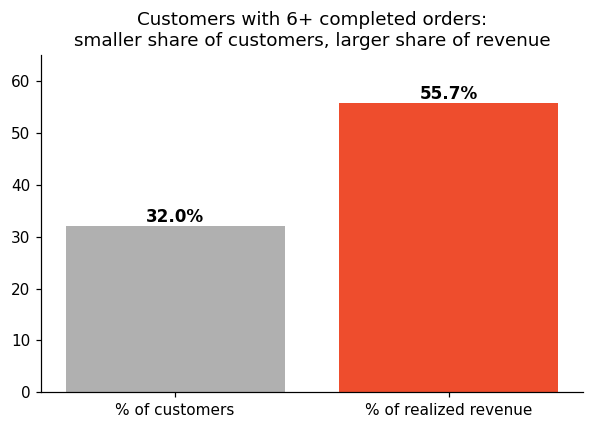

6+ orders: 32.0% of customers -> 55.7% of realized revenue


In [8]:
# Customer-share vs revenue-share for the 6+ orders group (the headline stat)
high_freq = rfm[rfm['frequency'] >= 6]
pct_customers = len(high_freq) / len(rfm) * 100
pct_revenue = high_freq['monetary'].sum() / rfm['monetary'].sum() * 100

fig, ax = plt.subplots(figsize=(5.5, 4))
bars = ax.bar(['% of customers', '% of realized revenue'],
               [pct_customers, pct_revenue],
               color=[COLOR_LIGHT, COLOR_PRIMARY])
for b in bars:
    ax.annotate(f'{b.get_height():.1f}%', (b.get_x()+b.get_width()/2, b.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylim(0, 65)
ax.set_title('Customers with 6+ completed orders:\nsmaller share of customers, larger share of revenue')
plt.tight_layout()
plt.savefig('chart_02_customer_vs_revenue_share.png', bbox_inches='tight')
plt.show()

print(f"6+ orders: {pct_customers:.1f}% of customers -> {pct_revenue:.1f}% of realized revenue")


---
## 04. Category Analysis

**Finding:** high-value customers do not show a distinctive category or
product preference. Home and Electronics dominate revenue for every
customer segment in roughly the same proportions.

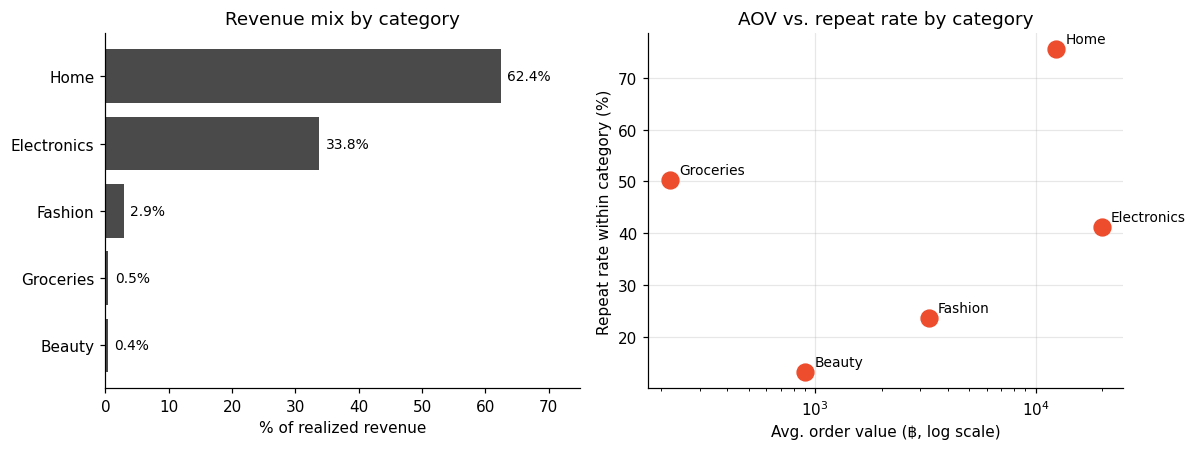

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# --- Left: revenue mix by category ---
cat_share_sorted = cat_share.sort_values(ascending=True)
axes[0].barh(cat_share_sorted.index, cat_share_sorted.values, color=COLOR_NEUTRAL)
axes[0].set_xlabel('% of realized revenue')
axes[0].set_title('Revenue mix by category')
for i, v in enumerate(cat_share_sorted.values):
    axes[0].text(v + 1, i, f'{v:.1f}%', va='center', fontsize=9)
axes[0].set_xlim(0, 75)

# --- Right: repeat rate vs AOV by category ---
cust_cat_orders = cat_completed.groupby(['category','customer_id'])['order_id'].nunique().reset_index(name='n')
repeat_rate = cust_cat_orders.groupby('category')['n'].apply(lambda x: (x>1).mean()*100)
order_cat_value = cat_completed.groupby(['order_id','category'])['line_total'].sum().reset_index()
aov = order_cat_value.groupby('category')['line_total'].mean()

axes[1].scatter(aov.values, repeat_rate.reindex(aov.index).values, s=120, color=COLOR_PRIMARY, zorder=3)
for cat in aov.index:
    axes[1].annotate(cat, (aov[cat], repeat_rate[cat]), textcoords="offset points",
                      xytext=(6,4), fontsize=9)
axes[1].set_xlabel('Avg. order value (\u0e3f, log scale)')
axes[1].set_xscale('log')
axes[1].set_ylabel('Repeat rate within category (%)')
axes[1].set_title('AOV vs. repeat rate by category')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('chart_03_category_mix_and_repeat.png', bbox_inches='tight')
plt.show()


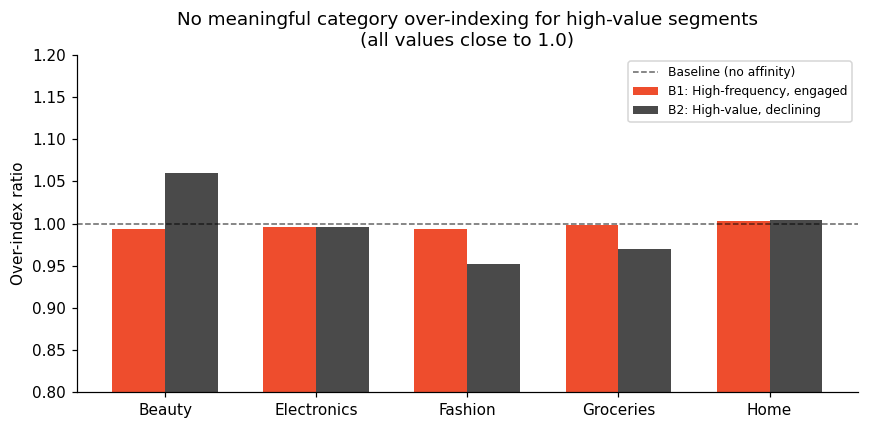

category                              Beauty  Electronics  Fashion  Groceries  Home
customer_segment                                                                   
B1: High-frequency, engaged             0.99          1.0     0.99       1.00   1.0
B2: High-value, declining engagement    1.06          1.0     0.95       0.97   1.0


In [10]:
# Category over-index for B1/B2 -- visualizing the null result
cat_seg = cat_completed.merge(rfm[['customer_id','customer_segment']], on='customer_id')

seg_cat_rev = cat_seg.groupby(['customer_segment','category'], observed=True)['line_total'].sum()
seg_totals = cat_seg.groupby('customer_segment', observed=True)['line_total'].sum()
seg_cat_share = (seg_cat_rev / seg_totals).unstack()

overall_share = cat_revenue / cat_revenue.sum()
over_index = seg_cat_share.div(overall_share, axis=1)

focus = over_index.loc[['B1: High-frequency, engaged','B2: High-value, declining engagement']]

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(focus.columns))
width = 0.35
ax.bar(x - width/2, focus.iloc[0].values, width, label='B1: High-frequency, engaged', color=COLOR_PRIMARY)
ax.bar(x + width/2, focus.iloc[1].values, width, label='B2: High-value, declining', color=COLOR_NEUTRAL)
ax.axhline(1.0, color='black', linestyle='--', linewidth=1, alpha=0.6, label='Baseline (no affinity)')
ax.set_xticks(x)
ax.set_xticklabels(focus.columns)
ax.set_ylabel('Over-index ratio')
ax.set_title('No meaningful category over-indexing for high-value segments\n(all values close to 1.0)')
ax.legend(fontsize=8)
ax.set_ylim(0.8, 1.2)
plt.tight_layout()
plt.savefig('chart_04_category_overindex.png', bbox_inches='tight')
plt.show()

print(focus.round(2))


---
## 05. Seller Analysis

**Finding:** the apparent FBS vs Standard performance gap was a
catalog-size artifact, not a real logistics-performance difference.
This chart is the clearest single visual for that story.

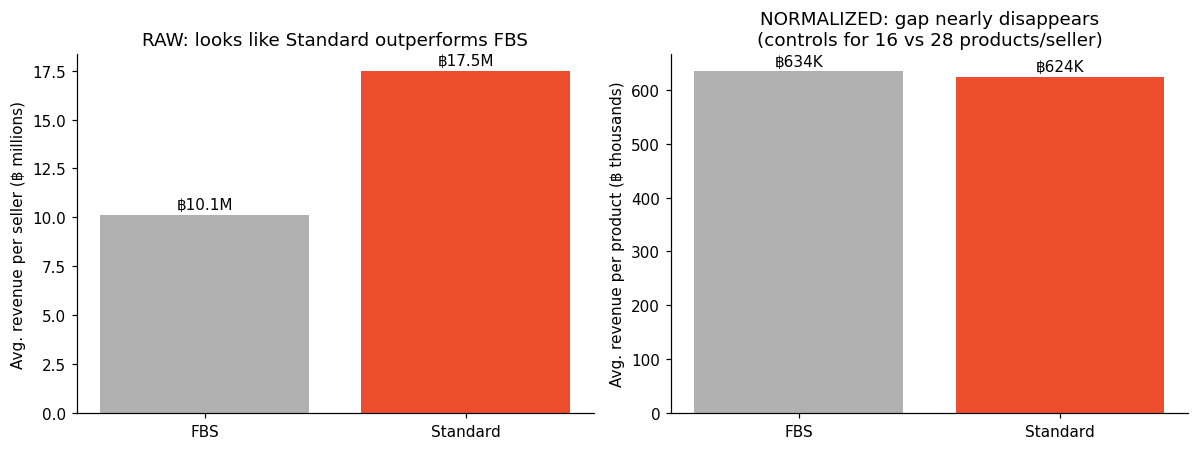

Raw revenue/seller: {'FBS': 10149339.0, 'Standard': 17473862.0}
Revenue/product: {'FBS': 634334.0, 'Standard': 624067.0}


In [11]:
oi_seller = order_items.merge(products[['product_id','seller_id']], on='product_id')
oi_seller = oi_seller.merge(sellers[['seller_id','seller_type','fbs_standard']], on='seller_id')
completed_seller = oi_seller[oi_seller['item_status']=='Completed'].merge(
    n_products.rename('n_products'), left_on='seller_id', right_index=True)

seller_agg = completed_seller.groupby('seller_id').agg(
    revenue=('line_total','sum'),
    n_products=('n_products','first'),
    fbs_standard=('fbs_standard','first'),
    seller_type=('seller_type','first')
).reset_index()
seller_agg['revenue_per_product'] = seller_agg['revenue'] / seller_agg['n_products']

raw = seller_agg.groupby('fbs_standard')['revenue'].mean()
norm = seller_agg.groupby('fbs_standard')['revenue_per_product'].mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].bar(raw.index, raw.values / 1e6, color=[COLOR_LIGHT, COLOR_PRIMARY])
axes[0].set_ylabel('Avg. revenue per seller (\u0e3f millions)')
axes[0].set_title('RAW: looks like Standard outperforms FBS')
for i, v in enumerate(raw.values):
    axes[0].text(i, v/1e6 + 0.3, f'\u0e3f{v/1e6:.1f}M', ha='center', fontsize=10)

axes[1].bar(norm.index, norm.values / 1000, color=[COLOR_LIGHT, COLOR_PRIMARY])
axes[1].set_ylabel('Avg. revenue per product (\u0e3f thousands)')
axes[1].set_title('NORMALIZED: gap nearly disappears\n(controls for 16 vs 28 products/seller)')
for i, v in enumerate(norm.values):
    axes[1].text(i, v/1000 + 10, f'\u0e3f{v/1000:.0f}K', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('chart_05_fbs_confound.png', bbox_inches='tight')
plt.show()

print("Raw revenue/seller:", raw.round(0).to_dict())
print("Revenue/product:", norm.round(0).to_dict())


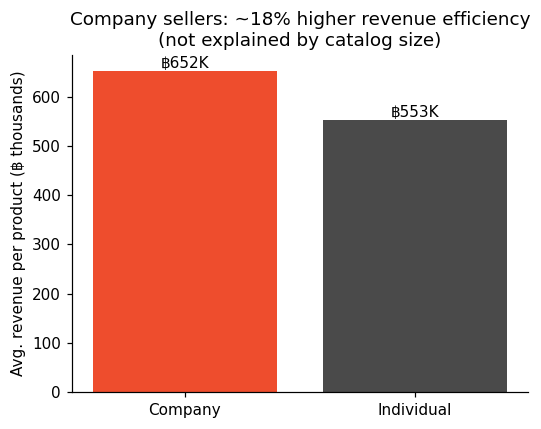

In [12]:
# Company vs Individual: revenue efficiency (real, moderate gap -- not a confound)
type_norm = seller_agg.groupby('seller_type')['revenue_per_product'].mean()

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(type_norm.index, type_norm.values/1000, color=[COLOR_PRIMARY, COLOR_NEUTRAL])
for b in bars:
    ax.annotate(f'\u0e3f{b.get_height():.0f}K', (b.get_x()+b.get_width()/2, b.get_height()),
                ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Avg. revenue per product (\u0e3f thousands)')
ax.set_title('Company sellers: ~18% higher revenue efficiency\n(not explained by catalog size)')
plt.tight_layout()
plt.savefig('chart_06_company_vs_individual.png', bbox_inches='tight')
plt.show()


---
## 06. Key Findings (reproduced from SQL)

1. **Purchase frequency showed the strongest and most consistent association
   with customer value.** Customers with 6+ completed orders were ~32% of
   the eligible customer base but generated ~55.7% of realized revenue.

2. **High-value customers did not show a distinctive category or product
   preference.** Category- and product-level over-index tests both
   returned ratios close to 1.0 for the B1/B2 segments.

3. **A seemingly large FBS vs Standard performance gap was a catalog-size
   artifact.** Revenue per product was nearly identical (~\u0e3f634K vs
   ~\u0e3f624K) once the deterministic 16-vs-28-products-per-seller
   difference was controlled for.

All three numbers above were computed independently in this notebook and
match the corresponding `.sql` files exactly (see Section 02).

---
## 07. Limitations

- This analysis is **observational**. All findings describe associations,
  not causal relationships.
- The customer segments (B0-B6) are analytical business rules created for
  this project, not an existing CRM segmentation system.
- The dataset is synthetic; some product-level fields (e.g. `product_name`)
  have limited variation and should be interpreted with caution.
- The 1-day difference between this notebook's median purchase-gap
  calculation and the SQL version (`PERCENT_RANK` vs pandas `.median()`
  interpolation) reflects a known method difference, not a data
  inconsistency -- see `03_category_analysis.sql` for details.
- Experimental data (e.g. A/B test results) and additional operational
  data would be needed to validate any of the proposed business actions.
